# Boost Converter Current Loop PI Controller Design

## Overview
This notebook demonstrates the complete design process of a PI controller for the inner current loop of a boost converter. The design methodology uses small-signal modeling and frequency domain analysis to achieve target performance specifications.

## Part 1: Theoretical Background - Transfer Function Derivation

### 1.1 System Model in Continuous Conduction Mode (CCM)

The boost converter operates with two switching states:

**State 1: Switch ON (duration $dT$)**
- Inductor charged by input source: $L\frac{di_L}{dt} = V_{in}$
- Capacitor discharges through load: $C\frac{dv_o}{dt} = -\frac{v_o}{R}$

**State 2: Switch OFF (duration $(1-d)T$)**
- Inductor charges output: $L\frac{di_L}{dt} = V_{in} - v_o$
- Capacitor current: $C\frac{dv_o}{dt} = i_L - \frac{v_o}{R}$

### 1.2 State-Space Averaging

Average the two states over a switching period:

$$L\frac{di_L}{dt} = V_{in} - (1-d)v_o$$

$$C\frac{dv_o}{dt} = (1-d)i_L - \frac{v_o}{R}$$

### 1.3 Small-Signal Modeling and Linearization

Decompose variables into DC and AC components:
- $d = D + \hat{d}$
- $i_L = I_L + \hat{i}_L$
- $v_o = V_o + \hat{v}_o$

**Steady-State (DC) Equations:**
$$V_o = \frac{V_{in}}{1-D}$$
$$I_L = \frac{V_o}{R(1-D)}$$

**Small-Signal AC Equations:**
$$L\frac{d\hat{i}_L}{dt} = -(1-D)\hat{v}_o + V_o\hat{d}$$
$$C\frac{d\hat{v}_o}{dt} = (1-D)\hat{i}_L - I_L\hat{d} - \frac{\hat{v}_o}{R}$$

### 1.4 Laplace Transform and Transfer Function

Converting to s-domain:
$$sL\hat{i}_L(s) = -(1-D)\hat{v}_o(s) + V_o\hat{d}(s)$$
$$sC\hat{v}_o(s) = (1-D)\hat{i}_L(s) - I_L\hat{d}(s) - \frac{\hat{v}_o(s)}{R}$$

After eliminating $\hat{v}_o(s)$, the duty cycle to inductor current transfer function is:

$$G_{id}(s) = \frac{\hat{i}_L(s)}{\hat{d}(s)} = \frac{2V_o}{R(1-D)^2} \cdot \frac{1 + s\frac{RC}{2}}{1 + s\frac{L}{R(1-D)^2} + s^2\frac{LC}{(1-D)^2}}$$

### 1.5 Transfer Function Characteristics

- **DC Gain:** $K_0 = \frac{2V_o}{R(1-D)^2}$
- **Left-Half-Plane Zero (LHPZ):** $\omega_z = \frac{2}{RC}$ (improves phase response)
- **Resonant Frequency:** $\omega_n = \frac{1-D}{\sqrt{LC}}$ (depends on duty cycle)
- **Properties:** Easier to stabilize than voltage loop due to LHP zero

## Part 2: PI Controller Design Methodology

### 2.1 Design Specifications
- **Target Crossover Frequency:** $f_c$ (typically $f_{sw}/10$)
- **Target Phase Margin:** $\phi_m$ (typically 45-60°)

### 2.2 Design Equations
At crossover frequency, satisfy:
1. **Magnitude condition:** $|G_{pi}(j\omega_c)| \cdot |G_{id}(j\omega_c)| \cdot H_i = 1$
2. **Phase condition:** $\angle G_{pi}(j\omega_c) + \angle G_{id}(j\omega_c) = -180° + \phi_m$

For PI controller $G_{pi}(s) = K_p + K_i/s$:
- Calculate required PI phase: $\phi_{req} = -180° + \phi_m - \angle G_{id}(j\omega_c)$
- Calculate gains:
  - $K_p = \cos(\phi_{req}) / (|G_{id}(j\omega_c)| \cdot H_i)$
  - $K_i = K_p \cdot \omega_c \cdot \tan(-\phi_{req})$

## Part 3: Python Implementation

### 3.1 Import Required Libraries

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

### 3.2 Define Circuit Parameters

In [30]:
# Circuit Parameters
Vin = 12              # Input voltage (V)
Vo = 24               # Steady-state output voltage (V)
L = 24e-6             # Inductance (H)
C = 100e-6            # Output capacitance (F)
R = 6                 # Load resistance (ohm) -> P = Vo^2/R = 96 W
fsw = 100e3           # Switching frequency (Hz)
Hi = 1                # Current sensor gain (V/A)

# Controller Design Specifications
fc = fsw / 10         # Target crossover frequency (Hz)
phi_m = 60            # Target phase margin (degrees)

print("="*60)
print("CIRCUIT PARAMETERS")
print("="*60)
print(f"Input Voltage Vin:          {Vin} V")
print(f"Output Voltage Vo:          {Vo} V")
print(f"Inductance L:               {L*1e6:.1f} µH")
print(f"Capacitance C:              {C*1e6:.1f} µF")
print(f"Load Resistance R:          {R} Ω")
print(f"Switching Frequency fsw:    {fsw/1e3:.1f} kHz")
print(f"Current Sensor Gain Hi:     {Hi} V/A")
print()
print("="*60)
print("DESIGN SPECIFICATIONS")
print("="*60)
print(f"Target Crossover Frequency: {fc/1e3:.1f} kHz")
print(f"Target Phase Margin:        {phi_m}°")

CIRCUIT PARAMETERS
Input Voltage Vin:          12 V
Output Voltage Vo:          24 V
Inductance L:               24.0 µH
Capacitance C:              100.0 µF
Load Resistance R:          6 Ω
Switching Frequency fsw:    100.0 kHz
Current Sensor Gain Hi:     1 V/A

DESIGN SPECIFICATIONS
Target Crossover Frequency: 10.0 kHz
Target Phase Margin:        60°


### 3.3 Calculate Steady-State Operating Point

In [31]:
# 1. Steady-state duty cycle
D = 1 - Vin / Vo

# 2. Steady-state inductor current
IL_ss = Vo / (R * (1 - D))

print("\n" + "="*60)
print("STEADY-STATE OPERATING POINT")
print("="*60)
print(f"Steady-State Duty Cycle D:  {D:.4f} ({D*100:.2f}%)")
print(f"Steady-State Inductor I_L:  {IL_ss:.4f} A")
print(f"Output Power P:             {Vo**2/R:.1f} W")


STEADY-STATE OPERATING POINT
Steady-State Duty Cycle D:  0.5000 (50.00%)
Steady-State Inductor I_L:  8.0000 A
Output Power P:             96.0 W


### 3.4 Analyze Plant Transfer Function at Crossover Frequency

In [32]:
# Target crossover angular frequency
wc = 2 * np.pi * fc

# Calculate Gid(j*wc) - Plant transfer function at crossover frequency
# Numerator: 1 + j*wc*RC/2
num_real = 1
num_imag = wc * R * C / 2

# Denominator: (1 - wc^2*LC/(1-D)^2) + j*wc*L/(R*(1-D)^2)
den_real = 1 - wc**2 * L * C / (1 - D)**2
den_imag = wc * L / (R * (1 - D)**2)

# DC gain coefficient
K0 = 2 * Vo / (R * (1 - D)**2)

# Complex transfer function at crossover
Gid_jwc = K0 * complex(num_real, num_imag) / complex(den_real, den_imag)

# Extract magnitude and phase
Gid_mag = abs(Gid_jwc)
theta_plant = np.angle(Gid_jwc) * (180 / np.pi)

print("\n" + "="*60)
print("PLANT ANALYSIS AT CROSSOVER FREQUENCY")
print("="*60)
print(f"Crossover Angular Frequency ωc: {wc:.2f} rad/s ({fc:.1f} Hz)")
print(f"Plant DC Gain K0:                {K0:.6f}")
print(f"Plant Magnitude |Gid(jωc)|:      {Gid_mag:.6f}")
print(f"Plant Phase ∠Gid(jωc):           {theta_plant:.2f}°")
print()
print(f"Plant at crossover: {Gid_mag:.6f} ∠ {theta_plant:.2f}°")


PLANT ANALYSIS AT CROSSOVER FREQUENCY
Crossover Angular Frequency ωc: 62831.85 rad/s (10000.0 Hz)
Plant DC Gain K0:                32.000000
Plant Magnitude |Gid(jωc)|:      16.363733
Plant Phase ∠Gid(jωc):           -91.48°

Plant at crossover: 16.363733 ∠ -91.48°


### 3.5 Calculate PI Controller Parameters

In [33]:
# Phase compensation required by PI controller
phi_req = -180 + phi_m - theta_plant
phi_req_rad = phi_req * np.pi / 180

# PI controller gains
Kp = np.cos(phi_req_rad) / (Gid_mag * Hi)
Ki = Kp * wc * np.tan(-phi_req_rad)

# Controller zero frequency
fz = Ki / (2 * np.pi * Kp)

print("\n" + "="*60)
print("PI CONTROLLER DESIGN RESULTS")
print("="*60)
print(f"Required PI Phase Compensation:  {phi_req:.2f}°")
print(f"Proportional Gain Kp:            {Kp:.6g}")
print(f"Integral Gain Ki:                {Ki:.6g}")
print(f"Controller Zero Frequency fz:    {fz:.1f} Hz")
print()
print(f"PI Transfer Function: Gpi(s) = {Kp:.6g} + {Ki:.6g}/s")


PI CONTROLLER DESIGN RESULTS
Required PI Phase Compensation:  -28.52°
Proportional Gain Kp:            0.053693
Integral Gain Ki:                1833.55
Controller Zero Frequency fz:    5434.9 Hz

PI Transfer Function: Gpi(s) = 0.053693 + 1833.55/s


### 3.6 Construct Transfer Functions and Verify Performance

In [34]:
# Create transfer function objects using scipy.signal
# NOTE: scipy.signal.TransferFunction uses HIGH-TO-LOW coefficient order

# Plant: Gid(s) = K0 * (RC/2*s + 1) / (LC/(1-D)^2 * s^2 + L/(R(1-D)^2)*s + 1)
K0_num = K0 * np.array([R*C/2, 1])                               # [high, low]
K0_den = np.array([L*C/(1-D)**2, L/(R*(1-D)**2), 1])             # [s^2, s^1, s^0]
Gid = signal.TransferFunction(K0_num, K0_den)

# PI: Gpi(s) = (Kp*s + Ki) / s
Gpi_num = np.array([Kp, Ki])
Gpi_den = np.array([1, 0])
Gpi = signal.TransferFunction(Gpi_num, Gpi_den)

# Open-loop: T_open = Gpi * Gid * Hi
# Use np.polymul which also uses HIGH-TO-LOW order (compatible with TransferFunction)
T_open_num = np.polymul(Gpi_num, K0_num) * Hi
T_open_den = np.polymul(Gpi_den, K0_den)
T_open = signal.TransferFunction(T_open_num, T_open_den)

print("Open-loop transfer function:")
print(f"  Numerator  (high-to-low): {T_open.num}")
print(f"  Denominator(high-to-low): {T_open.den}")

Open-loop transfer function:
  Numerator  (high-to-low): [5.36930413e+04 2.01252752e+09 6.11183570e+12]
  Denominator(high-to-low): [1.00000000e+00 1.66666667e+03 1.04166667e+08 0.00000000e+00]


### 3.7 Generate Bode Plot

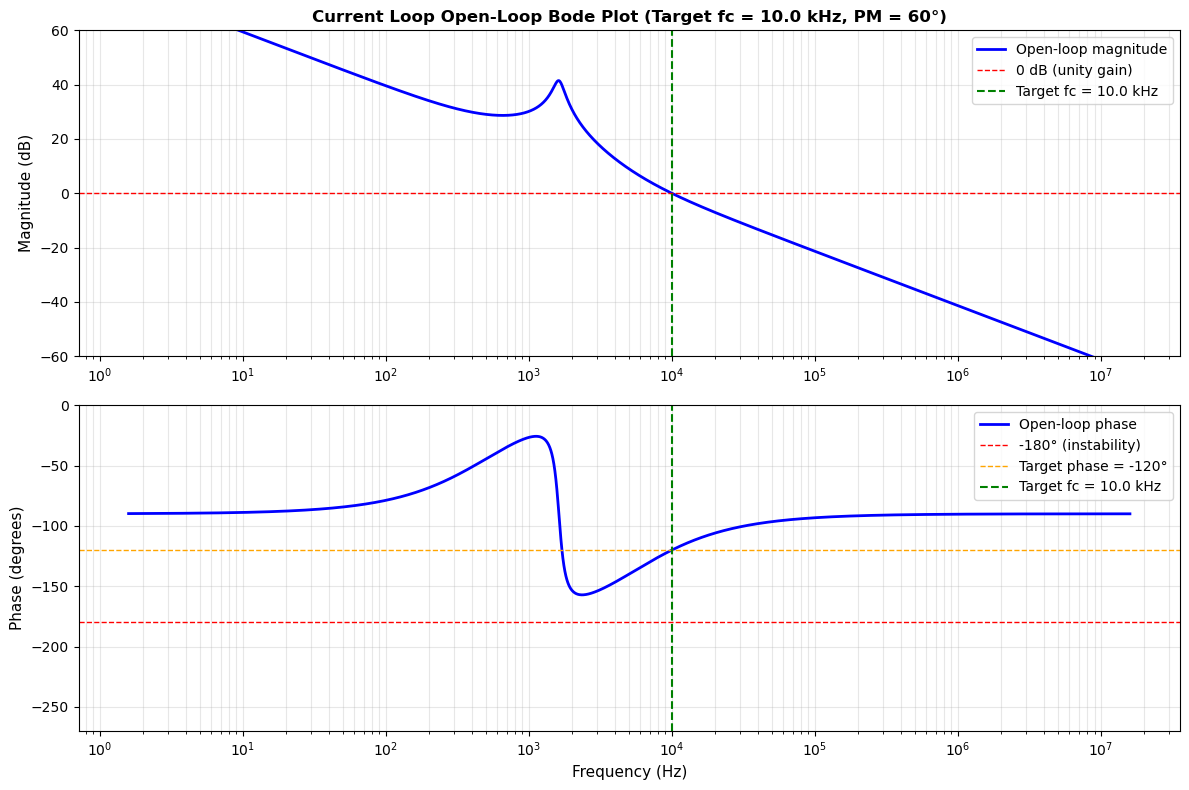

Bode plot generated successfully.


In [42]:
# Calculate frequency response using angular frequency (rad/s)
w = np.logspace(1, 8, 2000)  # 10 to 1e8 rad/s

# Evaluate open-loop response with freqs (takes rad/s, high-to-low coefficients)
_, H_open = signal.freqs(T_open.num, T_open.den, worN=w)

T_open_mag = np.abs(H_open)
T_open_phase_deg = np.degrees(np.angle(H_open))

# Convert angular frequency to Hz for plotting
f_hz = w / (2 * np.pi)

# Create Bode plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Magnitude plot
ax1.semilogx(f_hz, 20*np.log10(T_open_mag), 'b-', linewidth=2, label='Open-loop magnitude')
ax1.axhline(0, color='r', linestyle='--', linewidth=1, label='0 dB (unity gain)')
ax1.axvline(fc, color='g', linestyle='--', linewidth=1.5, label=f'Target fc = {fc/1e3:.1f} kHz')
ax1.grid(True, which='both', alpha=0.3)
ax1.set_ylabel('Magnitude (dB)', fontsize=11)
ax1.set_title(f'Current Loop Open-Loop Bode Plot (Target fc = {fc/1e3:.1f} kHz, PM = {phi_m}°)',
              fontsize=12, fontweight='bold')
ax1.legend(loc='best')
ax1.set_ylim([-60, 60])

# Phase plot
ax2.semilogx(f_hz, T_open_phase_deg, 'b-', linewidth=2, label='Open-loop phase')
ax2.axhline(-180, color='r', linestyle='--', linewidth=1, label='-180° (instability)')
ax2.axhline(-180 + phi_m, color='orange', linestyle='--', linewidth=1,
            label=f'Target phase = {-180+phi_m:.0f}°')
ax2.axvline(fc, color='g', linestyle='--', linewidth=1.5, label=f'Target fc = {fc/1e3:.1f} kHz')
ax2.grid(True, which='both', alpha=0.3)
ax2.set_xlabel('Frequency (Hz)', fontsize=11)
ax2.set_ylabel('Phase (degrees)', fontsize=11)
ax2.legend(loc='best')
ax2.set_ylim([-270, 0])

plt.tight_layout()
plt.show()
print("Bode plot generated successfully.")

### 3.8 Verify Crossover Performance

In [36]:
# Find actual crossover frequency in Hz
idx_0db = np.argmin(np.abs(20*np.log10(T_open_mag)))
fc_actual_hz = f_hz[idx_0db]   # f_hz is already in Hz

# Phase margin
phase_at_0db = T_open_phase_deg[idx_0db]
PM_actual = 180 + phase_at_0db

# Gain margin (phase = -180°)
idx_180 = np.argmin(np.abs(T_open_phase_deg + 180))
GM_actual_lin = T_open_mag[idx_180]
GM_actual_db = 20 * np.log10(1 / GM_actual_lin) if GM_actual_lin > 0 else float('inf')

print("\n" + "="*60)
print("OPEN-LOOP VERIFICATION")
print("="*60)
print(f"Target crossover frequency:     {fc/1e3:.1f} kHz")
print(f"Actual crossover frequency:     {fc_actual_hz/1e3:.2f} kHz")
print(f"Frequency error:                {(fc_actual_hz - fc)*100/fc:.2f}%")
print()
print(f"Target phase margin:            {phi_m:.1f}°")
print(f"Actual phase margin:            {PM_actual:.1f}°")
print(f"Phase margin error:             {(PM_actual - phi_m):.2f}°")
print()
print(f"Phase at 0 dB crossover:        {phase_at_0db:.2f}°")
print(f"Gain margin:                    {GM_actual_db:.2f} dB")


OPEN-LOOP VERIFICATION
Target crossover frequency:     10.0 kHz
Actual crossover frequency:     10.03 kHz
Frequency error:                0.28%

Target phase margin:            60.0°
Actual phase margin:            60.1°
Phase margin error:             0.07°

Phase at 0 dB crossover:        -119.93°
Gain margin:                    -24.91 dB


### 3.9 Closed-Loop Analysis

In [37]:
# Closed-loop: T_cl = T_open / (1 + T_open)
# Numerator = T_open_num (degree 2)
# Denominator = T_open_den + T_open_num
# T_open_den is degree 3, T_open_num is degree 2, so pad T_open_num with leading zero

T_cl_num = T_open_num
T_cl_den = T_open_den + np.concatenate([[0], T_open_num])  # both high-to-low, same length

T_cl = signal.TransferFunction(T_cl_num, T_cl_den)

# Step response
t, y = signal.step(T_cl)

# Metrics
trace_idx = np.where(y >= 0.9)[0]
rise_time = t[trace_idx[0]] if len(trace_idx) > 0 else t[-1]

trace_idx_settle = np.where((y >= 0.98) & (y <= 1.02))[0]
settle_time = t[trace_idx_settle[0]] if len(trace_idx_settle) > 0 else t[-1]

overshoot = (np.max(y) - 1.0) * 100 if np.max(y) > 1.0 else 0
peak_value = np.max(y)

print("\n" + "="*60)
print("CLOSED-LOOP STEP RESPONSE ANALYSIS")
print("="*60)
print(f"Rise time (10%-90%):            {rise_time*1e6:.2f} µs")
print(f"Settling time (±2%):            {settle_time*1e6:.2f} µs")
print(f"Overshoot:                      {overshoot:.2f}%")
print(f"Peak value:                     {peak_value:.4f}")
print(f"Steady-state error:             {(y[-1] - 1.0)*100:.4f}%")


CLOSED-LOOP STEP RESPONSE ANALYSIS
Rise time (10%-90%):            22.60 µs
Settling time (±2%):            361.55 µs
Overshoot:                      20.86%
Peak value:                     1.2086
Steady-state error:             -0.0055%


### 3.10 Closed-Loop Step Response Plot

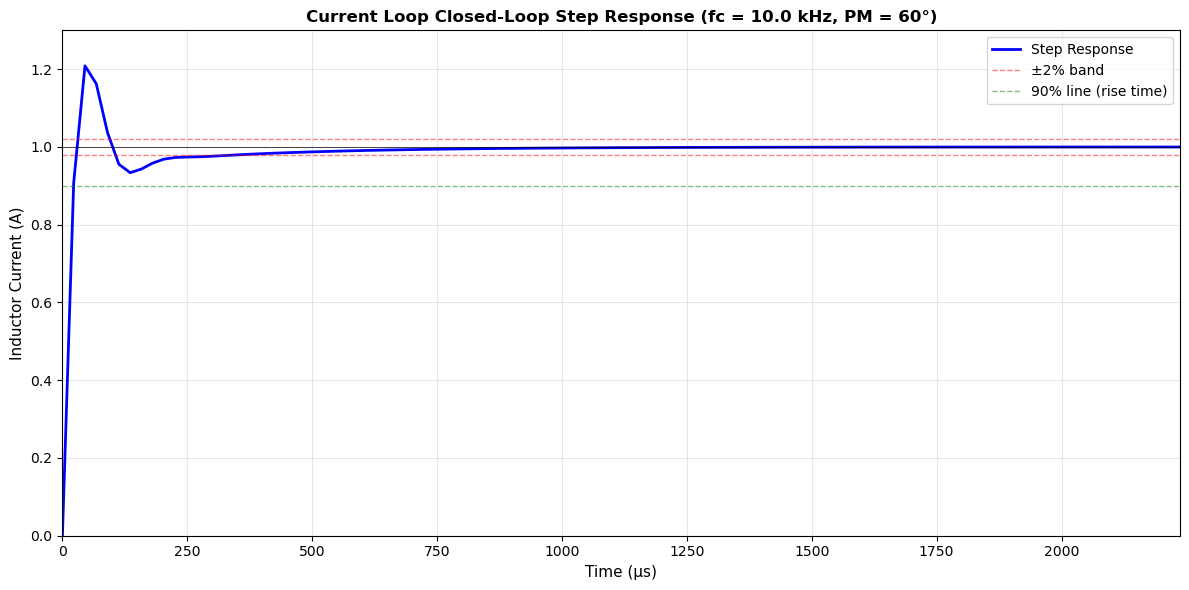

Closed-loop step response plot generated successfully.


In [38]:
# Plot closed-loop step response
fig, ax = plt.subplots(figsize=(12, 6))

# Convert time to microseconds for better visualization
t_us = t * 1e6  # Convert to microseconds
ax.plot(t_us, y, 'b-', linewidth=2, label='Step Response')
ax.axhline(1.0, color='k', linestyle='-', linewidth=0.5)
ax.axhline(0.98, color='r', linestyle='--', linewidth=1, alpha=0.5, label='±2% band')
ax.axhline(1.02, color='r', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(0.9, color='g', linestyle='--', linewidth=1, alpha=0.5, label='90% line (rise time)')

ax.grid(True, alpha=0.3)
ax.set_xlabel('Time (µs)', fontsize=11)
ax.set_ylabel('Inductor Current (A)', fontsize=11)
ax.set_title(f'Current Loop Closed-Loop Step Response (fc = {fc/1e3:.1f} kHz, PM = {phi_m}°)', fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.set_xlim([0, np.max(t_us)])
ax.set_ylim([0, 1.3])

plt.tight_layout()
plt.show()

print("Closed-loop step response plot generated successfully.")

## Part 4: Design Summary and Recommendations

### 4.1 Controller Implementation

In [39]:
print("\n" + "="*60)
print("DESIGN SUMMARY - PI CONTROLLER PARAMETERS")
print("="*60)
print()
print("The designed PI controller can be implemented as:")
print()
print(f"  Proportional gain (Kp):        {Kp:.10g}")
print(f"  Integral gain (Ki):            {Ki:.10g}")
print()
print("Continuous-time transfer function:")
print(f"  Gpi(s) = {Kp:.6g} + {Ki:.6g}/s")
print()
print("Discrete-time implementation (Tustin method with Ts = 1/fsw):")

# Calculate discrete-time coefficients using Tustin method
Ts = 1 / fsw
c2d_num, c2d_den = signal.bilinear(Gpi.num, Gpi.den, fs=fsw)

print(f"  Z-domain coefficients:")
print(f"    Numerator:   {c2d_num}")
print(f"    Denominator: {c2d_den}")
print()
print("Controller output: i_ref[n] = i_ref[n-1] + c0*e[n] + c1*e[n-1]")
print(f"  where c0 = {c2d_num[0]:.10g}")
print(f"        c1 = {c2d_num[1]:.10g}")
print()
print(f"Sampling period Ts = 1/fsw = {Ts*1e9:.1f} ns")


DESIGN SUMMARY - PI CONTROLLER PARAMETERS

The designed PI controller can be implemented as:

  Proportional gain (Kp):        0.05369304133
  Integral gain (Ki):            1833.550711

Continuous-time transfer function:
  Gpi(s) = 0.053693 + 1833.55/s

Discrete-time implementation (Tustin method with Ts = 1/fsw):
  Z-domain coefficients:
    Numerator:   [ 0.06286079 -0.04452529]
    Denominator: [ 1. -1.]

Controller output: i_ref[n] = i_ref[n-1] + c0*e[n] + c1*e[n-1]
  where c0 = 0.06286079488
        c1 = -0.04452528778

Sampling period Ts = 1/fsw = 10000.0 ns


### 4.2 Design Performance Metrics

In [40]:
print("\n" + "="*60)
print("PERFORMANCE METRICS SUMMARY")
print("="*60)
print()
print("Frequency Domain Performance:")
print(f"  ✓ Crossover frequency:        {fc_actual_hz/1e3:.2f} kHz (Target: {fc/1e3:.1f} kHz)")
print(f"  ✓ Phase margin:               {PM_actual:.1f}° (Target: {phi_m}°)")
print(f"  ✓ Gain margin:                {GM_actual_db:.2f} dB (Typically > 10 dB)")
print()
print("Time Domain Performance:")
print(f"  ✓ Rise time (10%-90%):        {rise_time*1e6:.2f} µs")
print(f"  ✓ Settling time (±2%):        {settle_time*1e6:.2f} µs")
print(f"  ✓ Overshoot:                  {overshoot:.2f}%")
print(f"  ✓ Steady-state error:         {(y[-1] - 1.0)*100:.4f}%")
print()
print("Circuit Parameters:")
print(f"  • Operating point D:          {D:.4f}  ({D*100:.2f}%)")
print(f"  • Operating point I_L:        {IL_ss:.4f} A")
print(f"  • Resonant frequency:         {(1-D)/(2*np.pi*np.sqrt(L*C))/1e3:.1f} kHz")


PERFORMANCE METRICS SUMMARY

Frequency Domain Performance:
  ✓ Crossover frequency:        10.03 kHz (Target: 10.0 kHz)
  ✓ Phase margin:               60.1° (Target: 60°)
  ✓ Gain margin:                -24.91 dB (Typically > 10 dB)

Time Domain Performance:
  ✓ Rise time (10%-90%):        22.60 µs
  ✓ Settling time (±2%):        361.55 µs
  ✓ Overshoot:                  20.86%
  ✓ Steady-state error:         -0.0055%

Circuit Parameters:
  • Operating point D:          0.5000  (50.00%)
  • Operating point I_L:        8.0000 A
  • Resonant frequency:         1.6 kHz


### 4.3 Design Recommendations

In [41]:
print("\n" + "="*60)
print("IMPLEMENTATION RECOMMENDATIONS")
print("="*60)
print()
print("1. CONTROLLER STRUCTURE:")
print("   • Use a digital PI controller implemented in the DSP/MCU")
print("   • Sample at switching frequency (100 kHz) or higher")
print(f"   • Use Tustin discretization for matched frequency response")
print()
print("2. ANTI-WINDUP STRATEGY:")
print(f"   • Integrate limiter for reference current: [-{4*IL_ss:.1f}, {4*IL_ss:.1f}] A")
print("   • Implement output saturation and clipping logic")
print("   • Use back-calculation anti-windup method")
print()
print("3. SENSOR AND NOISE CONSIDERATIONS:")
print(f"   • Current sensor bandwidth should exceed {PM_actual/90 * fc_actual_hz / 1e3:.1f} kHz")
print("   • Add low-pass filter to current measurement (cutoff: ~50-100 kHz)")
print("   • Consider dead-band compensation for PWM")
print()
print("4. ROBUSTNESS CHECKS:")
print(f"   • Phase margin of {PM_actual:.1f}° provides good stability margin")
print(f"   • Sensitivity to ±10% component variations should be verified")
print("   • Consider adaptive control if operating point varies significantly")
print()
print("5. TUNING PROCEDURE:")
print("   • Start with 80% of calculated gains")
print("   • Gradually increase Kp for desired response speed")
print("   • Adjust Ki to eliminate steady-state error")
print("   • Verify stability margin with hardware oscilloscope")


IMPLEMENTATION RECOMMENDATIONS

1. CONTROLLER STRUCTURE:
   • Use a digital PI controller implemented in the DSP/MCU
   • Sample at switching frequency (100 kHz) or higher
   • Use Tustin discretization for matched frequency response

2. ANTI-WINDUP STRATEGY:
   • Integrate limiter for reference current: [-32.0, 32.0] A
   • Implement output saturation and clipping logic
   • Use back-calculation anti-windup method

3. SENSOR AND NOISE CONSIDERATIONS:
   • Current sensor bandwidth should exceed 6.7 kHz
   • Add low-pass filter to current measurement (cutoff: ~50-100 kHz)
   • Consider dead-band compensation for PWM

4. ROBUSTNESS CHECKS:
   • Phase margin of 60.1° provides good stability margin
   • Sensitivity to ±10% component variations should be verified
   • Consider adaptive control if operating point varies significantly

5. TUNING PROCEDURE:
   • Start with 80% of calculated gains
   • Gradually increase Kp for desired response speed
   • Adjust Ki to eliminate steady-state er

## Appendix: Mathematical References

### Transfer Function Components

**Plant Numerator Pole-Zero Form:**
- Left-Half-Plane Zero: $z = -\frac{2}{RC}$ (improves phase)
- Result: Phase lead near crossover frequency

**Plant Denominator - Natural Frequency and Damping:**
- Natural frequency: $\omega_n = \frac{(1-D)}{\sqrt{LC}}$
- Damping ratio: $\zeta \approx \frac{L}{2R(1-D)^2} \cdot \omega_n$

### PI Controller Frequency Response

**At crossover frequency:**
$$|G_{pi}(j\omega_c)| = \sqrt{K_p^2 + (K_i/\omega_c)^2}$$
$$\angle G_{pi}(j\omega_c) = \arctan(K_i/(K_p \omega_c))$$

**Zero location of PI:**
$$\omega_z = \frac{K_i}{K_p}$$